# 01 EDA: what does the customer base look like?

In [9]:
import sys
from pathlib import Path
ROOT = next(
    (parent for parent in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
     if (parent / 'src' / 'feature_engineering.py').is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', 50)
from feature_engineering import load_raw, engineer_features

raw = load_raw()
print(raw.shape)
raw.head()

(45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
print(raw['y'].value_counts(normalize=True).round(3))
print(raw['balance'].describe())

y
no     0.883
yes    0.117
Name: proportion, dtype: float64
count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64


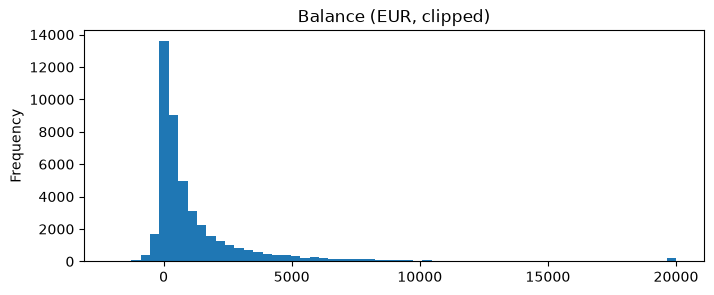

In [11]:
raw['balance'].clip(-2000, 20000).plot.hist(bins=60, figsize=(8, 3),
    title='Balance (EUR, clipped)')
plt.show()

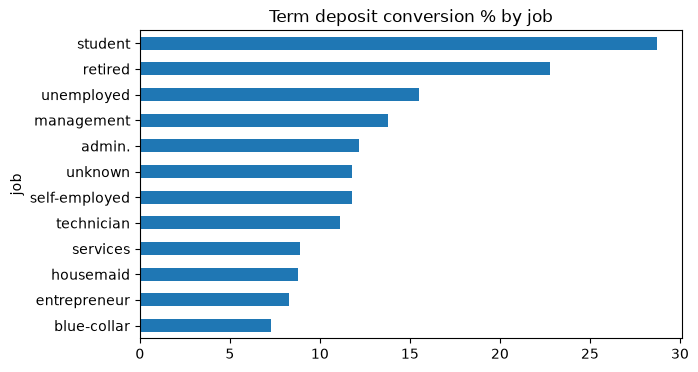

In [12]:
def conv(col, data=raw):
    return data.groupby(col, observed=True)['y'].apply(lambda s: (s == 'yes').mean() * 100).round(1)

conv('job').sort_values().plot.barh(figsize=(7, 4), title='Term deposit conversion % by job')
plt.show()

In [13]:
print(conv(pd.cut(raw['age'], [0, 25, 35, 50, 60, 100])))
print(conv('poutcome'))

age
(0, 25]      24.0
(25, 35]     12.0
(35, 50]      9.4
(50, 60]     10.1
(60, 100]    42.3
Name: y, dtype: float64
poutcome
failure    12.6
other      16.7
success    64.7
unknown     9.2
Name: y, dtype: float64


**Takeaways to note for the interview:** class imbalance (about 12% subscribe), students and retirees convert best, and balance is heavily right-skewed.